In [1]:
import pandas as pd
pd.set_option('display.max_rows', 500)
import numpy as np
import matplotlib.pyplot as plt

import requests
from bs4 import BeautifulSoup
import os
import s3fs
import ast
import json


from sklearn.linear_model import RidgeCV, ElasticNetCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score

In [2]:
os.environ['AWS_S3_ENDPOINT']
S3_ENDPOINT_URL = 'http://' + os.environ['AWS_S3_ENDPOINT']
fs = s3fs.S3FileSystem(client_kwargs = {'endpoint_url' :S3_ENDPOINT_URL })
fs.ls('mlepennec-ensae')
BUCKET = 'mlepennec-ensae'
FILE_OUT_S3 = '/data_movies_final_selected_merged.csv'  # Chemin dans le bucket
FILE_OUT_PATH = BUCKET + FILE_OUT_S3       # Chemin complet S3

with fs.open(FILE_OUT_PATH, mode='rb') as f_out:
    data_movies_final_selected_merged = pd.read_csv(f_out)

In [ ]:
data_movies_final_selected_merged['runtime'] = data_movies_final_selected_merged['runtime'].fillna(value = -1)
data_movies_final_selected_merged['rang'] = data_movies_final_selected_merged['rang'].fillna(value = -1)
data_movies_final_selected_merged['vote_prec'] = data_movies_final_selected_merged['vote_prec'].fillna(value = -1)


data_movies_final_selected_merged['big_awards_before_film_1'] = data_movies_final_selected_merged['big_awards_before_film_1'].fillna(value = 0)
data_movies_final_selected_merged['small_awards_before_film_1'] = data_movies_final_selected_merged['small_awards_before_film_1'].fillna(value = 0)
data_movies_final_selected_merged['big_awards_before_film_2'] = data_movies_final_selected_merged['big_awards_before_film_2'].fillna(value = 0)
data_movies_final_selected_merged['small_awards_before_film_2'] = data_movies_final_selected_merged['small_awards_before_film_2'].fillna(value = 0)
data_movies_final_selected_merged['big_awards_before_film_3'] = data_movies_final_selected_merged['big_awards_before_film_3'].fillna(value = 0)
data_movies_final_selected_merged['small_awards_before_film_3'] = data_movies_final_selected_merged['small_awards_before_film_3'].fillna(value = 0)
data_movies_final_selected_merged['big_awards_before_film_4'] = data_movies_final_selected_merged['big_awards_before_film_4'].fillna(value = 0)
data_movies_final_selected_merged['small_awards_before_film_4'] = data_movies_final_selected_merged['small_awards_before_film_4'].fillna(value = 0)
data_movies_final_selected_merged['big_awards_before_film_5'] = data_movies_final_selected_merged['big_awards_before_film_5'].fillna(value = 0)
data_movies_final_selected_merged['small_awards_before_film_5'] = data_movies_final_selected_merged['small_awards_before_film_5'].fillna(value = 0)
data_movies_final_selected_merged['big_awards_before_film_6'] = data_movies_final_selected_merged['big_awards_before_film_6'].fillna(value = 0)
data_movies_final_selected_merged['small_awards_before_film_6'] = data_movies_final_selected_merged['small_awards_before_film_6'].fillna(value = 0)
data_movies_final_selected_merged['big_awards_before_film_7'] = data_movies_final_selected_merged['big_awards_before_film_7'].fillna(value = 0)
data_movies_final_selected_merged['small_awards_before_film_7'] = data_movies_final_selected_merged['small_awards_before_film_7'].fillna(value = 0)
data_movies_final_selected_merged['big_awards_before_film_8'] = data_movies_final_selected_merged['big_awards_before_film_8'].fillna(value = 0)
data_movies_final_selected_merged['small_awards_before_film_8'] = data_movies_final_selected_merged['small_awards_before_film_8'].fillna(value = 0)
data_movies_final_selected_merged['big_awards_before_film_9'] = data_movies_final_selected_merged['big_awards_before_film_9'].fillna(value = 0)
data_movies_final_selected_merged['small_awards_before_film_9'] = data_movies_final_selected_merged['small_awards_before_film_9'].fillna(value = 0)
data_movies_final_selected_merged['big_awards_before_film_10'] = data_movies_final_selected_merged['big_awards_before_film_10'].fillna(value = 0)
data_movies_final_selected_merged['small_awards_before_film_10'] = data_movies_final_selected_merged['small_awards_before_film_10'].fillna(value = 0)
data_movies_final_selected_merged['big_awards_before_film'] = data_movies_final_selected_merged['big_awards_before_film'].fillna(value = 0)
data_movies_final_selected_merged['small_awards_before_film'] = data_movies_final_selected_merged['small_awards_before_film'].fillna(value = 0)

In [44]:
df = data_movies_final_selected_merged.sample(frac=1, random_state=42)
df=df[df['vote_count']>=5]
df=df.drop(['release_date'], axis=1)
df=df[df['budget']<=3000000000000]


In [45]:
features = df.drop('vote_average', axis = 1)
label = df['vote_average']

In [ ]:
#num_features = features.select_dtypes(include= ['int32', 'float64', 'int64']).columns
#transformer = Pipeline(steps= [
#    ('scaler', StandardScaler())
#])
#preprocessor = ColumnTransformer(transformers= [
#    ('features', transformer, num_features)
#])

#preprocessor.fit_transform(features)

array([[-0.49027181, -0.26539931, -0.37288444, ..., -0.14099583,
        -0.08947948, -0.22402684],
       [-0.20813478, -0.24511294,  2.68179603, ..., -0.14099583,
        -0.08947948, -0.22402684],
       [ 0.63827631, -0.22820763, -0.37288444, ..., -0.14099583,
         0.25243127, -0.22402684],
       ...,
       [ 0.10221595, -0.24173188, -0.37288444, ..., -0.14099583,
        -0.08947948, -0.22402684],
       [-0.82883625, -0.26539931, -0.37288444, ..., -0.14099583,
        -0.08947948, -0.22402684],
       [ 0.18685706, -0.17580118,  2.68179603, ..., -0.14099583,
        -0.08947948, -0.22402684]], shape=(30630, 48))

In [46]:
X_train, X_test, y_train, y_test = train_test_split(features, label, test_size=0.1, random_state=42)


# Vérification
print(f"Taille totale : {len(df)}")
print(f"Train : {len(X_train)} lignes ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test : {len(X_test)} lignes ({len(X_test)/len(df)*100:.1f}%)")

Taille totale : 30629
Train : 27566 lignes (90.0%)
Test : 3063 lignes (10.0%)


In [47]:
weights_train = X_train['vote_count']
X_train=X_train.drop('vote_count', axis=1)
weights_test = X_test['vote_count']
X_test=X_test.drop('vote_count', axis=1)

ajouter le retraitement des maisons de production

In [48]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),         # transforme les données
    columns=X_train.columns,               # garde les mêmes noms de colonnes
    index=X_train.index                    # garde les mêmes index
)
X_test_scaled = pd.DataFrame(
    scaler.fit_transform(X_test),         # transforme les données
    columns=X_test.columns,               # garde les mêmes noms de colonnes
    index=X_test.index                    # garde les mêmes index
)

In [64]:
rf = RandomForestRegressor(random_state=42)

In [ ]:
#pip_reg = Pipeline(steps=[
#    ('preproc', preprocessor),
#    ('classifier', rf)
#])
#pip_reg_fitted = pip_reg.fit(X_train, y_train)
#y_predict = pip_reg_fitted.predict(X_test)

In [77]:
rf.fit(X_train_scaled[selection_variables], y_train, sample_weight=weights_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [78]:
y_predict = rf.predict(X_test_scaled[selection_variables])

In [80]:
mean_squared_error(y_test, y_predict)

0.8085927811408361

In [ ]:
0.7804969167317118

In [67]:
importances = rf.feature_importances_

# Créer un DataFrame pour mieux visualiser
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

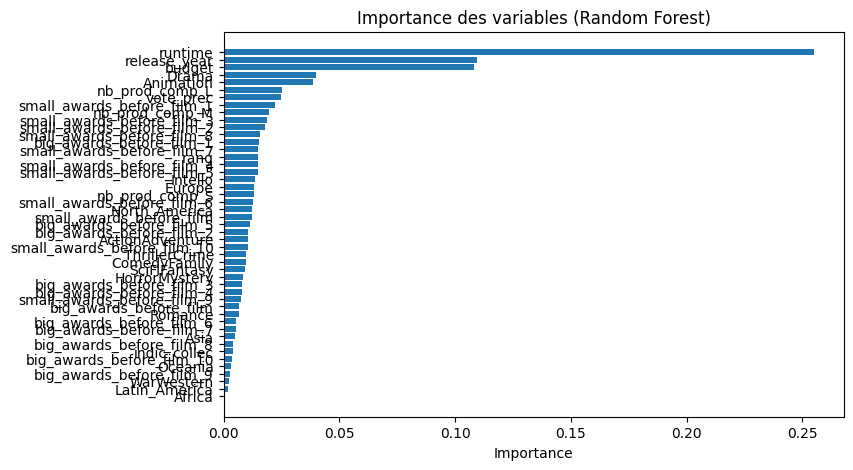

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(feature_importances['Feature'], feature_importances['Importance'])
plt.gca().invert_yaxis()  # Pour avoir la plus importante en haut
plt.xlabel("Importance")
plt.title("Importance des variables (Random Forest)")
plt.show()


In [76]:
selection_variables=list(feature_importances.iloc[:-10,0])

In [26]:
import pandas as pd
import statsmodels.api as sm

def backward_selection_WLS(X, y, weights=None, verbose=True):
    """
    Sélection backward (élimination) basée sur l'AIC avec régression WLS.
    
    Paramètres :
    ------------
    X : pandas.DataFrame
        Variables explicatives.
    y : pandas.Series ou array-like
        Variable à expliquer.
    weights : array-like, optionnel
        Poids pour la régression WLS (si None, équivaut à OLS).
    verbose : bool
        Si True, affiche les étapes de la sélection.
    
    Retourne :
    -----------
    model : statsmodels.regression.linear_model.RegressionResults
        Le modèle final après sélection backward.
    selected_vars : list
        Liste des variables retenues dans le modèle final.
    """

    # On ajoute une constante
    X_ = sm.add_constant(X, has_constant='add')
    remaining_vars = list(X_.columns)
    best_bic = float('inf')
    improved = True

    while improved and len(remaining_vars) > 1:
        improved = False
        bic_with_candidates = []

        for var in remaining_vars:
            if var == 'const':
                continue  # ne jamais retirer la constante
            candidate_vars = [v for v in remaining_vars if v != var]
            model = sm.WLS(y, X_[candidate_vars], weights=weights).fit()
            bic_with_candidates.append((model.bic, var, model))

        # On cherche la variable dont la suppression améliore le plus l'AIC
        bic_with_candidates.sort(key=lambda x: x[0])
        best_candidate_bic, removed_var, candidate_model = bic_with_candidates[0]

        if best_candidate_bic < best_bic - 1e-6:  # amélioration significative
            if verbose:
                print(f"Supprime {removed_var} : AIC = {best_candidate_bic:.3f}")
            remaining_vars.remove(removed_var)
            best_bic = best_candidate_bic
            best_model = candidate_model
            improved = True
        else:
            if verbose:
                print("Aucune amélioration supplémentaire de l’AIC.")
            break

    if verbose:
        print("\n=== Modèle final ===")
        print(f"Variables retenues : {remaining_vars}")
        print(f"BIC final : {best_bic:.3f}")

    return best_model, remaining_vars


In [27]:
model, selected_vars = backward_selection_WLS(X_train_scaled, y_train, weights=weights_train)


Supprime Africa : AIC = 108494.360
Supprime WarWestern : AIC = 108484.154
Supprime small_awards_before_film_9 : AIC = 108473.999
Supprime budget : AIC = 108463.855
Supprime small_awards_before_film_6 : AIC = 108453.841
Supprime small_awards_before_film : AIC = 108443.867
Supprime small_awards_before_film_5 : AIC = 108433.935
Supprime big_awards_before_film_7 : AIC = 108424.010
Supprime Intello : AIC = 108414.241
Supprime big_awards_before_film_4 : AIC = 108404.577
Supprime big_awards_before_film_6 : AIC = 108395.054
Supprime big_awards_before_film : AIC = 108386.065
Supprime Latin_America : AIC = 108377.389
Supprime big_awards_before_film_1 : AIC = 108368.736
Supprime Asia : AIC = 108360.156
Supprime small_awards_before_film_7 : AIC = 108353.127
Supprime small_awards_before_film_4 : AIC = 108346.102
Supprime big_awards_before_film_8 : AIC = 108339.704
Supprime ThrillerCrime : AIC = 108333.664
Supprime big_awards_before_film_9 : AIC = 108328.073
Supprime nb_prod_comp_M : AIC = 108323.50

In [28]:
selected_vars.remove('const')

In [29]:
final_model = sm.WLS(y_train, sm.add_constant(X_train_scaled[selected_vars])).fit()

In [30]:
y_pred = final_model.predict(sm.add_constant(X_test[selected_vars]))


In [31]:
r2_score(y_test, y_pred)

-61305.72259508938

In [43]:
X_train[X_train['budget']>=250000000].sort_values('budget')

,runtime,indic_collec,rang,vote_prec,release_year,budget,North_America,Europe,Asia,Latin_America,...,big_awards_before_film_7,small_awards_before_film_7,big_awards_before_film_8,small_awards_before_film_8,big_awards_before_film_9,small_awards_before_film_9,big_awards_before_film_10,small_awards_before_film_10,big_awards_before_film,small_awards_before_film
41801,136.0,1,8.0,7.3,2017,2.500000e+08,1,0,0,0,...,0.0,0.0,1.0,18.0,0.0,5.0,0.0,2.0,0.0,0.0
19218,106.0,0,-1.0,-1.0,1999,2.501596e+08,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
39799,148.0,1,26.0,6.9,2015,2.533755e+08,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0
40030,136.0,1,7.0,7.1,2015,2.533755e+08,1,0,0,0,...,0.0,14.0,0.0,0.0,0.0,0.0,0.0,10.0,1.0,27.0
40588,147.0,1,3.0,7.6,2016,2.553253e+08,1,0,0,0,...,6.0,0.0,0.0,0.0,1.0,16.0,0.0,16.0,0.0,0.0
40425,151.0,1,2.0,6.5,2016,2.553253e+08,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,11.0,0.0,0.0
25179,104.0,1,3.0,6.8,2006,2.553435e+08,2,1,0,0,...,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0
27680,150.0,1,2.0,6.7,2008,2.561601e+08,1,3,0,0,...,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0
37134,131.0,1,5.0,7.1,2014,2.588531e+08,1,1,0,0,...,0.0,0.0,0.0,0.0,17.0,0.0,12.0,0.0,0.0,0.0
38228,144.0,1,3.0,7.6,2014,2.588531e+08,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,24.0,0.0
